# Diego's Workspace

Diego, this is your notebook. Work on your model here.

In [60]:
# import required libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer



# Exploring the Data

In [61]:
data = pd.read_csv('E:/machine_learning_1/ML2_group_assignment/ML2-GroupProject/raw/mushrooms.csv')

data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [62]:
data.describe().T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [64]:
data.shape

(8124, 23)

In [65]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

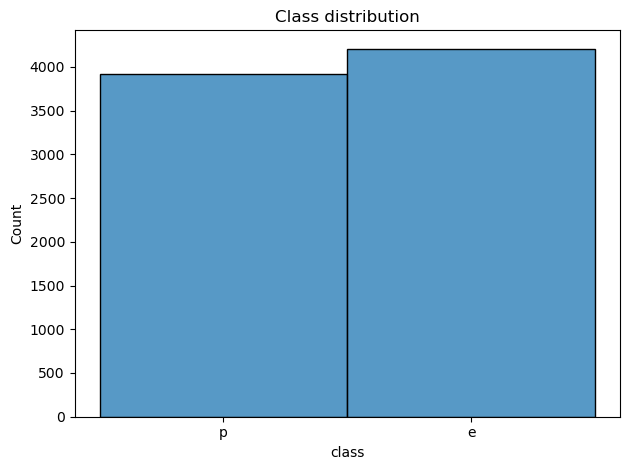

In [66]:
sns.histplot(data['class'])
plt.title('Class distribution')
plt.tight_layout()

# get the percentage for each class 
data['class'].value_counts(normalize=True)

### Nominal and Ordinal Features 
- **Nominal**: Categories with no natural order
- **Ordinal**: Categories with a meaningful order 
---------------------------------------------------

- Nominal Example: `cap-color` (red, brown, green...) -> red is not "greater than" brown
- Ordinal Example: `ring-number` (none < one < two) -> there's a clear ranking

---------------------------------------------------
- The mushrooms dataset has mostly nominal features but also contains ordinary. 
- Its important to recognize which is which as we need to encode the variables as currently its written in text and some algorithms will not be able to run 

In [67]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [68]:
nominal_features = ['cap-shape', 'cap-surface', 'cap-color',
                    'bruises', 'odor', 'gill-attachment', 'gill-size',
                    'gill-color', 'stalk-shape', 'stalk-root',
                    'stalk-surface-above-ring', 'stalk-surface-below-ring',
                    'stalk-color-above-ring', 'stalk-color-below-ring',
                    'veil-type', 'veil-color', 'ring-type',
                    'spore-print-color', 'population', 'habitat']

ordinal_features = ['gill-spacing', 'ring-number']

In [69]:
# Separate features and target
X = data.drop(columns=['class'])
y = data['class'].map({
    'p': 0,
    'e': 1
})

# Step 1: Split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split remaining into train (64%) and validation (16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print(f'Train size:      {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})')
print(f'Validation size: {X_val.shape[0]} ({X_val.shape[0]/len(X):.0%})')
print(f'Test size:       {X_test.shape[0]} ({X_test.shape[0]/len(X):.0%})')

Train size:      5199 (64%)
Validation size: 1300 (16%)
Test size:       1625 (20%)


In [70]:
# defining the ordinal categories explicitly to apply the correct order (BASED ON THE COLUMN INFO ON KAGGLE)

ordinal_categories = [['c', 'w', 'd'],  # grill-spacing: close < crowded < distant
                      ['n', 'o', 't']]  # ring-number: none < one < two

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_features),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
])

# Fit ONLY on train, transform all three
# by fitting on the train data WE AVOID LEAKAGE
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded   = preprocessor.transform(X_val)
X_test_encoded  = preprocessor.transform(X_test)

print(f'Encoded train shape: {X_train_encoded.shape}')


Encoded train shape: (5199, 114)


## Feature Importance 

### Why are we encoding again? 

 `preprocessor` (ColumnTransformer) -> for model training

Uses  `OneHotEncoder` on nominal features -> expands columns (e.g.  `cap-color` becomes 10 binary columns)
After OHE you lose the original column names, so  `.corr()` becomes messy and hard to read

 `encoder_corr` (OrdinalEncoder on everything) -> just for correlation analysis

Keeps all features as single columns with their original names
Makes the heatmap readable

In [71]:
encoder_corr = OrdinalEncoder()
X_train_corr = pd.DataFrame(
    encoder_corr.fit_transform(X_train),
    columns=X_train.columns
)

In [72]:
# get feature correlation

corr = X_train_corr.corr()

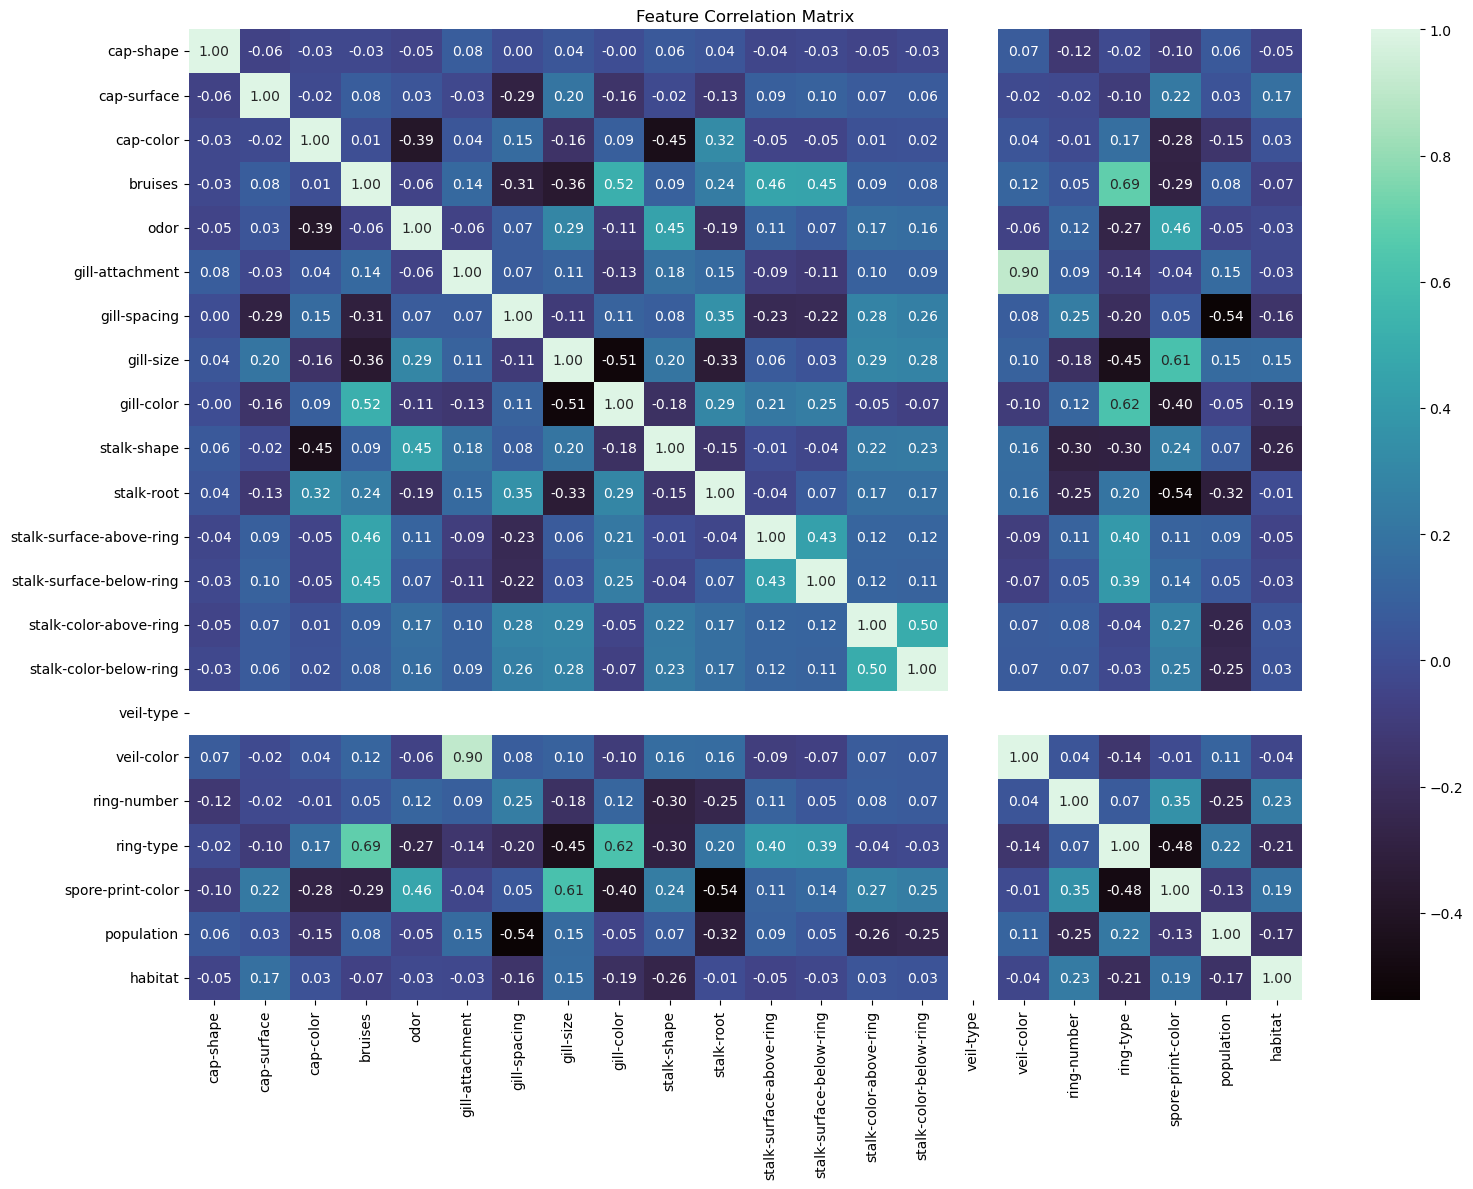

In [73]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='mako')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Variable Correlation Analysis

- In this section we will dive deeper into the variables and figure out which ones are correlated in order to find which ones we have to drop
- While multicolinearity does not affect some algorithms (e.g Trees) its imoportant that we remove them for the remaining models
- For this case: [`gill-attachment` and `veil-color`], [`bruises` and `ring-type`], [`gill-color` and `ring-type`], [`gill-size` and `spore-print-color`] have high correlation with min: **0.613** and max: **0.904**

In [74]:
# The threshold is the correlation value we get (we will do 0.6 as it has some variables)
threshold = 0.6

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_df.sort_values(by='Correlation', key=abs, ascending=False)

,Feature 1,Feature 2,Correlation
1,gill-attachment,veil-color,0.904371
0,bruises,ring-type,0.689793
3,gill-color,ring-type,0.616929
2,gill-size,spore-print-color,0.613333


# Model (1): Logistic Regression 

- Simple, interpretable
- Works well with our one-hot encoded features 

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get feature names after encoding
feature_names = preprocessor.get_feature_names_out()

# Identify columns to drop due to multicollinearity (threshold > 0.6)
# From correlation analysis:
# gill-attachment & veil-color (0.904) -> drop veil-color
# bruises & ring-type (0.690) -> drop ring-type
# gill-color & ring-type (0.617) -> already dropping ring-type
# gill-size & spore-print-color (0.613) -> drop spore-print-color

cols_to_drop = ['veil-color', 'ring-type', 'spore-print-color']

# Find indices of encoded columns that belong to the features we want to drop
drop_indices = [i for i, name in enumerate(feature_names) 
                if any(name.startswith(f'nominal__{col}_') for col in cols_to_drop)]

print(f'Dropping {len(drop_indices)} encoded columns from: {cols_to_drop}')
print(f'Original shape: {X_train_encoded.shape[1]} -> New shape: {X_train_encoded.shape[1] - len(drop_indices)}')

Dropping 18 encoded columns from: ['veil-color', 'ring-type', 'spore-print-color']
Original shape: 114 -> New shape: 96


In [76]:
import numpy as np

# Remove multicollinear columns (only for Logistic Regression)
keep_indices = [i for i in range(X_train_encoded.shape[1]) if i not in drop_indices]

X_train_lr = X_train_encoded[:, keep_indices]
X_val_lr = X_val_encoded[:, keep_indices]
X_test_lr = X_test_encoded[:, keep_indices]

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train)

# Predictions on validation set
y_val_pred_lr = lr_model.predict(X_val_lr)

print('=== Logistic Regression - Validation Set ===')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}')
print()
print(classification_report(y_val, y_val_pred_lr, target_names=['Poisonous', 'Edible']))

=== Logistic Regression - Validation Set ===
Accuracy: 1.0000

              precision    recall  f1-score   support

   Poisonous       1.00      1.00      1.00       627
      Edible       1.00      1.00      1.00       673

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



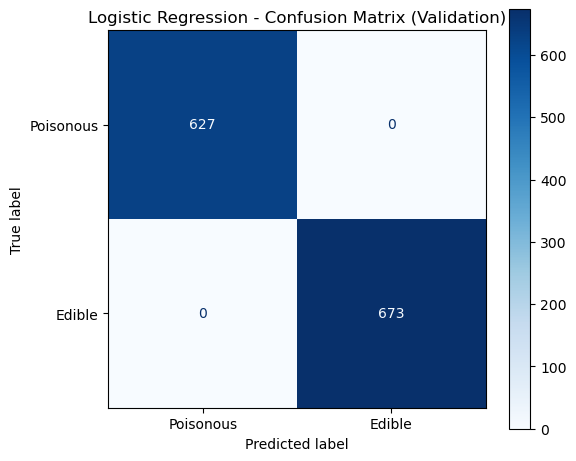

In [77]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred_lr, 
                                         display_labels=['Poisonous', 'Edible'],
                                         cmap='Blues', ax=ax)
ax.set_title('Logistic Regression - Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

# Model(2): Decision Tree

# Model(3): Random Forest

# Model (4): Gradient Boosting

# Model(5): Naive Bayes - Gaussian 

# Model(6): KNN

# Things to do for next time
1. Dimensionality reduction how can we incorporate it 
- review the code and know wtf is going on so i can explain it to the team 
